In [1]:
import os
import sys

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt
import gc

lib_svraster = "/home/dotamthuc/Works/Projects/Compress3DGS/svraster"
sys.path.insert(0, lib_svraster)

lib_compress= "/home/dotamthuc/Works/Projects/Compress3DGS/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_compress)

np.set_printoptions(precision=6, suppress=True, linewidth=np.inf, threshold=np.inf)


from src.config import cfg, update_argparser, update_config
from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.utils.image_utils import im_tensor2np, viz_tensordepth

from libs.raht import raht
import constriction
from sklearn.cluster import KMeans


import numpy as np
from src.utils import octree_utils
import svraster_cuda

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


In [2]:

SH_C0 = 0.28209479177387814
SH_C1 = 0.4886025119029199
SH_C2 = [
    1.0925484305920792,
    -1.0925484305920792,
    0.31539156525252005,
    -1.0925484305920792,
    0.5462742152960396
]
SH_C3 = [
    -0.5900435899266435,
    2.890611442640554,
    -0.4570457994644658,
    0.3731763325901154,
    -0.4570457994644658,
    1.445305721320277,
    -0.5900435899266435
]
def computeSHBasisInstance(directions):

    directions_norm = np.sqrt((directions**2).sum(axis=1, keepdims=True))
    directions_norm = directions / directions_norm
    size = directions_norm.shape[0]
    print(f"Dir size={size}")

    # DEG 0
    # result = SH_C0 * sh0
    result = [np.ones(size) * SH_C0]

    #DEG 1
    x, y, z = directions_norm[:, 0], directions_norm[:, 1], directions_norm[:, 2]
    # result = result - SH_C1 * y * sh[0] + SH_C1 * z * sh[1] - SH_C1 * x * sh[2]
    result.append( - SH_C1 * y )
    result.append( + SH_C1 * z )
    result.append( - SH_C1 * x )

    #DEG 2
    xx = x * x
    yy = y * y
    zz = z * z
    xy = x * y
    yz = y * z
    xz = x * z

    # result = result + \
    #     SH_C2[0] * xy * sh[3] + \
    #     SH_C2[1] * yz * sh[4] + \
    #     SH_C2[2] * (2.0 * zz - xx - yy) * sh[5] + \
    #     SH_C2[3] * xz * sh[6] + \
    #     SH_C2[4] * (xx - yy) * sh[7]
    result.append( SH_C2[0] * xy )
    result.append( SH_C2[1] * yz )
    result.append( SH_C2[2] * (2.0 * zz - xx - yy) )
    result.append( SH_C2[3] * xz )
    result.append( SH_C2[4] * (xx - yy) )

    
    # DEG 3
    # result = result + \
    #     SH_C3[0] * y * (3.0 * xx - yy) * sh[8] + \
    #     SH_C3[1] * xy * z * sh[9] + \
    #     SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[10] + \
    #     SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[11] + \
    #     SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[12] + \
    #     SH_C3[5] * z * (xx - yy) * sh[13] + \
    #     SH_C3[6] * x * (xx - 3.0 * yy) * sh[14] 
    result.append( SH_C3[0] * y * (3.0 * xx - yy) )
    result.append( SH_C3[1] * xy * z)
    result.append( SH_C3[2] * y * (4.0 * zz - xx - yy) )
    result.append( SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) )
    result.append( SH_C3[4] * x * (4.0 * zz - xx - yy) )
    result.append( SH_C3[5] * z * (xx - yy) )
    result.append( SH_C3[6] * x * (xx - 3.0 * yy) )

    result = np.stack(result, axis=-1)
    return result


In [3]:

# SH_C0 = 0.28209479177387814
# SH_C1 = 0.4886025119029199
# SH_C2 = [
#     1.0925484305920792,
#     -1.0925484305920792,
#     0.31539156525252005,
#     -1.0925484305920792,
#     0.5462742152960396
# ]
# SH_C3 = [
#     -0.5900435899266435,
#     2.890611442640554,
#     -0.4570457994644658,
#     0.3731763325901154,
#     -0.4570457994644658,
#     1.445305721320277,
#     -0.5900435899266435
# ]
# def computeColorFromSH(
#         input_dir, coefs_mask,
#     ):

#     dir_norm = np.sqrt(np.sum((input_dir**2)))
#     # print(f"dir={dir} dir_norm={dir_norm}")
#     input_dir = input_dir / dir_norm
#     # print(f"Dir={input_dir}")

#     # // The implementation is loosely based on code for
#     # // "Differentiable Point-Based Radiance Fields for
#     # // Efficient View Synthesis" by Zhang et al. (2022)
#     sh = coefs_mask[1:, :]
#     sh0 = coefs_mask[0, :]

#     # DEG 0
#     result = SH_C0 * sh0

#     #DEG 1
#     x,y,z = input_dir[0], input_dir[1], input_dir[2]
#     result = result - SH_C1 * y * sh[0] + SH_C1 * z * sh[1] - SH_C1 * x * sh[2]

#     #DEG 2
#     xx = x * x
#     yy = y * y
#     zz = z * z
#     xy = x * y
#     yz = y * z
#     xz = x * z
#     result = result + \
#         SH_C2[0] * xy * sh[3] + \
#         SH_C2[1] * yz * sh[4] + \
#         SH_C2[2] * (2.0 * zz - xx - yy) * sh[5] + \
#         SH_C2[3] * xz * sh[6] + \
#         SH_C2[4] * (xx - yy) * sh[7]
    
#     # DEG 3
#     result = result + \
#         SH_C3[0] * y * (3.0 * xx - yy) * sh[8] + \
#         SH_C3[1] * xy * z * sh[9] + \
#         SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[10] + \
#         SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[11] + \
#         SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[12] + \
#         SH_C3[5] * z * (xx - yy) * sh[13] + \
#         SH_C3[6] * x * (xx - 3.0 * yy) * sh[14] 

#     result = result
#     # result[result<=0] = 0.0
#     return result


In [3]:

root_path=f"/home/dotamthuc/Works/Projects/Compress3DGS/Experiments"
path_dataset=f"f{root_path}/data/mip-nerf-360"
path_output_base=f"{root_path}/output/SVRaster/mip-nerf-360"
scene_list = [
    "bicycle",
    "bonsai",
    "counter",
    "flowers",
    "garden",
    "kitchen",
    "room",
    "stump",
    "treehill",
]

path_source=f"{path_dataset}/{scene_list[0]}"
path_output=f"{path_output_base}/{scene_list[0]}"

import argparse
parser = argparse.ArgumentParser(
    description="Sparse voxels raster rendering.")
parser.add_argument('model_path')
args = parser.parse_args(args=[f"{path_output}"])
update_config(os.path.join(args.model_path, 'config.yaml'))


In [4]:
# Load data
data_pack = DataPack(
    source_path=cfg.data.source_path,
    image_dir_name=cfg.data.image_dir_name,
    res_downscale=cfg.data.res_downscale,
    res_width=cfg.data.res_width,
    skip_blend_alpha=cfg.data.skip_blend_alpha,
    alpha_is_white=cfg.model.white_background,
    data_device=cfg.data.data_device,
    use_test=cfg.data.eval,
    test_every=cfg.data.test_every,
    camera_params_only=False,
)

# Load model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=cfg.model.n_samp_per_vox,
    sh_degree=cfg.model.sh_degree,
    ss=cfg.model.ss,
    white_background=cfg.model.white_background,
    black_background=cfg.model.black_background,
)

Read dataset in COLMAP format.
Read dataset in 9.019 seconds.


In [5]:
checkpoint = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/mip-nerf-360/bicycle"
voxel_model.load_iteration(checkpoint, -1)

30000

In [6]:
checkpoint = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/mip-nerf-360/bicycle"
voxel_model.load_iteration(checkpoint, -1)

tr_render_opt = {
    'track_max_w': False,
    'output_depth': False,
    'output_normal': False,
    'output_T': False,
}
psnr_lst = []
views = data_pack.get_test_cameras()
for idx, view in enumerate(views):
    render_pkg = voxel_model.render(view, **tr_render_opt)
    rendering = render_pkg['color']
    gt = view.image.cuda()
    mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
    psnr = -10 * torch.log10(mse)
    psnr_lst.append(psnr.item())
print('PSNR:', np.mean(psnr_lst))

PSNR: 25.237311248779296


# No transform

In [7]:
RESULTS = {}

In [8]:
# color_transform = dict(np.load("/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRasterCompressed-DirColor/mip-nerf-360/bicycle/directional_color_transform_precomputed.npz"))
# directional_color_transform_ = color_transform["directional_color_transform"]
# directional_color_inverse_transform_ = color_transform["directional_color_transform_inverse"]

directional_color_transform = np.eye(48)
directional_color_inverse_transform = np.eye(48)

shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 
shs_coefficients = (shs_coefficients.reshape(-1, 16 * 3) @ directional_color_transform).reshape(-1, 16, 3)


In [9]:
all_num_coefs = []
all_psnr = []

for ncoefs in range(1, 49):
    # truncated_coefs = np.zeros_like(shs_coefficients)
    # truncated_coefs[:, :ncoefs] = shs_coefficients[:, :ncoefs, :]
    truncated_coefs = (shs_coefficients.reshape(-1, 48)[:, :ncoefs] @ directional_color_inverse_transform[:ncoefs, :]).reshape(-1, 16, 3)

    voxel_model._sh0 = torch.tensor(truncated_coefs[:, 0, :]).cuda().to(torch.float32)
    voxel_model._shs = torch.tensor(truncated_coefs[:, 1:]).cuda().to(torch.float32)
    psnr_lst = []
    views = data_pack.get_test_cameras()
    for idx, view in enumerate(views):
        render_pkg = voxel_model.render(view, **tr_render_opt)
        rendering = render_pkg['color']
        gt = view.image.cuda()
        mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
        psnr = -10 * torch.log10(mse)
        psnr_lst.append(psnr.item())

    all_num_coefs.append(ncoefs)
    all_psnr.append(np.mean(psnr_lst))
    print(f'num_coefs={ncoefs} PSNR={np.mean(psnr_lst)}')


RESULTS["no_transform"] = (all_num_coefs, all_psnr)

num_coefs=1 PSNR=12.83190414428711
num_coefs=2 PSNR=14.522895698547364
num_coefs=3 PSNR=21.69475456237793
num_coefs=4 PSNR=21.812948760986327
num_coefs=5 PSNR=21.96185615539551
num_coefs=6 PSNR=22.118846740722656
num_coefs=7 PSNR=22.21815605163574
num_coefs=8 PSNR=22.318151321411133
num_coefs=9 PSNR=22.422066955566407
num_coefs=10 PSNR=22.525505828857423
num_coefs=11 PSNR=22.631068496704103
num_coefs=12 PSNR=22.753701553344726
num_coefs=13 PSNR=22.80216552734375
num_coefs=14 PSNR=22.84446746826172
num_coefs=15 PSNR=22.88448844909668
num_coefs=16 PSNR=22.915234985351564
num_coefs=17 PSNR=22.936620712280273
num_coefs=18 PSNR=22.957137451171874
num_coefs=19 PSNR=23.040683212280275
num_coefs=20 PSNR=23.12397315979004
num_coefs=21 PSNR=23.194091339111328
num_coefs=22 PSNR=23.315071792602538
num_coefs=23 PSNR=23.427875289916994
num_coefs=24 PSNR=23.510494384765625
num_coefs=25 PSNR=23.57421600341797
num_coefs=26 PSNR=23.640164260864257
num_coefs=27 PSNR=23.703085632324218
num_coefs=28 PSNR=2

# KLT transform

In [11]:
checkpoint = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/mip-nerf-360/bicycle"
voxel_model.load_iteration(checkpoint, -1)

shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 

XtX = shs_coefficients.reshape(-1, 48).T @ shs_coefficients.reshape(-1, 48)
U, S, Vt = np.linalg.svd(XtX)
klt_transform = U
shs_coefficients = (shs_coefficients.reshape(-1, 16 * 3) @ klt_transform).reshape(-1, 16, 3)


In [12]:
all_num_coefs = []
all_psnr = []

for ncoefs in range(1, 49):
    # truncated_coefs = np.zeros_like(shs_coefficients)
    # truncated_coefs[:, :ncoefs] = shs_coefficients[:, :ncoefs, :]
    truncated_coefs = (shs_coefficients.reshape(-1, 48)[:, :ncoefs] @ klt_transform.T[:ncoefs, :]).reshape(-1, 16, 3)

    voxel_model._sh0 = torch.tensor(truncated_coefs[:, 0, :]).cuda().to(torch.float32)
    voxel_model._shs = torch.tensor(truncated_coefs[:, 1:]).cuda().to(torch.float32)
    psnr_lst = []
    views = data_pack.get_test_cameras()
    for idx, view in enumerate(views):
        render_pkg = voxel_model.render(view, **tr_render_opt)
        rendering = render_pkg['color']
        gt = view.image.cuda()
        mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
        psnr = -10 * torch.log10(mse)
        psnr_lst.append(psnr.item())

    all_num_coefs.append(ncoefs)
    all_psnr.append(np.mean(psnr_lst))
    print(f'num_coefs={ncoefs} PSNR={np.mean(psnr_lst)}')


RESULTS["no_transform"] = (all_num_coefs, all_psnr)

num_coefs=1 PSNR=20.56783233642578
num_coefs=2 PSNR=21.61976264953613
num_coefs=3 PSNR=21.779437713623047
num_coefs=4 PSNR=22.182548370361328
num_coefs=5 PSNR=22.33616584777832
num_coefs=6 PSNR=22.46363754272461
num_coefs=7 PSNR=22.82868522644043
num_coefs=8 PSNR=23.080520629882812
num_coefs=9 PSNR=23.1874617767334
num_coefs=10 PSNR=23.30933708190918
num_coefs=11 PSNR=23.763580474853516
num_coefs=12 PSNR=23.96108207702637
num_coefs=13 PSNR=24.364935913085937
num_coefs=14 PSNR=24.59583465576172
num_coefs=15 PSNR=24.909329986572267
num_coefs=16 PSNR=24.94657043457031
num_coefs=17 PSNR=24.972110748291016
num_coefs=18 PSNR=24.98960708618164
num_coefs=19 PSNR=25.015121994018553
num_coefs=20 PSNR=25.037315216064453
num_coefs=21 PSNR=25.04864990234375
num_coefs=22 PSNR=25.05453285217285
num_coefs=23 PSNR=25.09341163635254
num_coefs=24 PSNR=25.11003723144531
num_coefs=25 PSNR=25.131416702270506
num_coefs=26 PSNR=25.140921936035156
num_coefs=27 PSNR=25.151257934570314
num_coefs=28 PSNR=25.17658

# NEW COLOR TRANSFORM

In [94]:
from sklearn.cluster import KMeans

views = data_pack.get_test_cameras() 
list_dir = []
for idx, view in enumerate(views):
    ndup_per_voxels, _ = voxel_model.collect_render_infos(view, **tr_render_opt)
    all_directions_view_i = np.concatenate([
        (voxel_model.vox_center[ndup_per_voxels>ndup] - view.position[None, :]).cpu().numpy()
        for ndup in [0, 1]
    ])
    norm = np.sqrt((all_directions_view_i**2).sum(axis=1, keepdims=True))
    print("norm", norm.shape)
    all_directions_view_i = all_directions_view_i / norm
    
    kmeans = KMeans(n_clusters=64, random_state=0, n_init='auto')
    kmeans.fit(all_directions_view_i)
    picked_directions = kmeans.cluster_centers_
    picked_directions = picked_directions / np.sqrt((picked_directions**2).sum(axis=1, keepdims=True))

    list_dir.append(picked_directions)

norm (5858661, 1)
norm (6012546, 1)
norm (5462761, 1)
norm (5008419, 1)
norm (4941958, 1)
norm (5025263, 1)
norm (5239915, 1)
norm (4801274, 1)
norm (4786413, 1)
norm (4755448, 1)
norm (4496312, 1)
norm (4918084, 1)
norm (4548772, 1)
norm (4443822, 1)
norm (4301358, 1)
norm (4167846, 1)
norm (4387860, 1)
norm (4370920, 1)
norm (4233705, 1)
norm (4215434, 1)
norm (4268825, 1)
norm (4248888, 1)
norm (4177518, 1)
norm (3773819, 1)
norm (3653981, 1)


In [95]:

list_all_view_dir = np.concatenate(list_dir)

(array([ 35.,  67., 140., 210., 254., 278., 253., 203., 121.,  39.]),
 array([-0.397758, -0.264227, -0.130695,  0.002837,  0.136369,  0.269901,  0.403433,  0.536965,  0.670497,  0.804029,  0.93756 ]),
 <BarContainer object of 10 artists>)

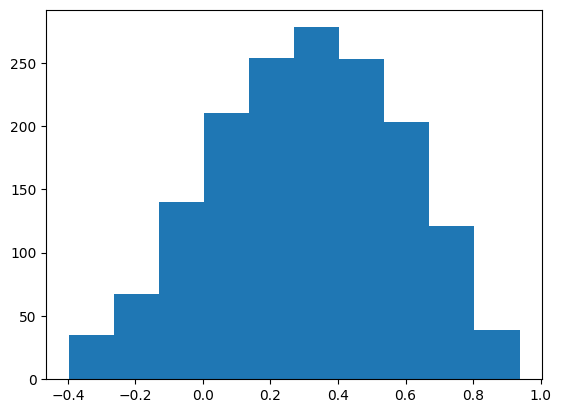

In [98]:
plt.hist(list_all_view_dir[:, 1])

In [ ]:

list_all_view_dir = np.concatenate(list_dir)
transformM = []
i=0
for dir in list_all_view_dir:
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(len(list_all_view_dir)*3, 16*3)
print(f"transformM.shape={transformM.shape}")


transformM.shape=(1600, 16, 3, 3)
transformM.shape=(4800, 48)


In [120]:
M = transformM[:, :]
MtM = (M.T @ M)

U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U @ np.diag(1/np.sqrt(S)) @ Vt

# U =  U[:, np.argsort(S)]
transform = MtM @ MtT_sqrt_inv
inv_transform = MtT_sqrt_inv

In [ ]:

list_all_view_dir = np.concatenate(list_dir)
basisM = []
for dir in list_all_view_dir:
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    basisM.append(out_dir)
basisM = np.array(basisM)
basisM = np.transpose(basisM, (0, 3, 1, 2)).reshape(len(list_all_view_dir), 3, 16, 3)
print(f"basisM.shape={basisM.shape}") # 

# gram_matrix = (basisM.T @ basisM)
# print(f"gram_matrix.shape={gram_matrix.shape}") # 

# U, S, Vt = np.linalg.svd(gram_matrix)
# sqrt_inv_basisM = U @ np.diag(1/np.sqrt(S)) @ Vt

# directional_color_transform = (gram_matrix @ sqrt_inv_basisM).astype(np.float32)
# directional_color_inverse_transform = (sqrt_inv_basisM).astype(np.float32)


directional_color_transform = np.eye(16*3, dtype=np.float32)
directional_color_inverse_transform = np.eye(16*3, dtype=np.float32)
for d in range(3):
    sub_basisM = basisM[:, d, :, d]
    gram_matrix = (sub_basisM.T @ sub_basisM)

    # sqrt_diag = np.diag(np.sqrt(np.diag(gram_matrix)))
    sqrt_inv_diag = np.diag(1/np.sqrt(np.diag(gram_matrix)))

    gram_matrix_normed = sqrt_inv_diag @ gram_matrix @ sqrt_inv_diag

    U, S, Vt = np.linalg.svd(gram_matrix_normed)
    print("S", S)
    sqrt_inv_sub_basisM = U @ np.diag(1/np.sqrt(S)) @ Vt

    transform = (gram_matrix_normed @ sqrt_inv_sub_basisM).astype(np.float32)
    inv_transform = (sqrt_inv_sub_basisM).astype(np.float32)

    dbegin, dend = d*16, (d+1)*16
    directional_color_transform[dbegin:dend, dbegin:dend] = transform
    directional_color_inverse_transform[dbegin:dend, dbegin:dend] = inv_transform
    

basisM.shape=(1600, 3, 16, 3)
S [2.867471 2.43885  1.948905 1.847236 1.630381 1.236597 1.201063 0.926744 0.728064 0.503193 0.276378 0.22441  0.117984 0.028065 0.023531 0.001129]
S [2.867471 2.43885  1.948905 1.847236 1.630381 1.236597 1.201063 0.926744 0.728064 0.503193 0.276378 0.22441  0.117984 0.028065 0.023531 0.001129]
S [2.867471 2.43885  1.948905 1.847236 1.630381 1.236597 1.201063 0.926744 0.728064 0.503193 0.276378 0.22441  0.117984 0.028065 0.023531 0.001129]


In [122]:
checkpoint = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/mip-nerf-360/bicycle"
voxel_model.load_iteration(checkpoint, -1)

tr_render_opt = {
    'track_max_w': False,
    'output_depth': False,
    'output_normal': False,
    'output_T': False,
}
psnr_lst = []
views = data_pack.get_test_cameras()
for idx, view in enumerate(views):
    render_pkg = voxel_model.render(view, **tr_render_opt)
    rendering = render_pkg['color']
    gt = view.image.cuda()
    mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
    psnr = -10 * torch.log10(mse)
    psnr_lst.append(psnr.item())
print('PSNR:', np.mean(psnr_lst))

PSNR: 25.237311248779296


In [ ]:
shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 
temp = (shs_coefficients.reshape(-1, 16 * 3) @ directional_color_transform).reshape(-1, 16, 3)

In [114]:
variance = np.std(temp.reshape(-1, 48), axis=0)
order = np.argsort(-variance)
print("variance:\n", variance.reshape(16, 3))
directional_color_transform = directional_color_transform[:, order]
directional_color_inverse_transform = directional_color_inverse_transform[order, :]

variance:
 [[0.732898 0.573638 1.920255]
 [0.142802 0.041564 0.838546]
 [0.70173  0.163994 0.777276]
 [0.126964 0.079074 0.310598]
 [0.347151 0.091761 0.524503]
 [0.090034 0.042539 0.056697]
 [0.082774 0.047168 0.055492]
 [0.081471 0.077488 0.091807]
 [0.065651 0.050402 0.091577]
 [0.096448 0.101653 0.110732]
 [0.092789 0.098314 0.097743]
 [0.109194 0.10363  0.107807]
 [0.099294 0.095548 0.111958]
 [0.090213 0.066891 0.075514]
 [0.098663 0.113214 0.09622 ]
 [0.090106 0.097799 0.102374]]


In [123]:
shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 
temp = (shs_coefficients.reshape(-1, 16 * 3) @ transform).reshape(-1, 16, 3)

In [124]:
variance = np.std(temp.reshape(-1, 48), axis=0)
order = np.argsort(-variance)
print("variance:\n", variance.reshape(16, 3))
# directional_color_transform = directional_color_transform[:, order]
# directional_color_inverse_transform = directional_color_inverse_transform[order, :]

variance:
 [[12.209184 10.198511 17.875226]
 [ 5.762263  4.819036  8.377505]
 [ 1.776859  1.609952  2.458046]
 [ 1.78466   1.615708  2.462417]
 [ 0.954539  0.946318  1.087699]
 [ 2.744741  2.342823  3.875252]
 [ 2.862612  2.463806  4.101226]
 [ 1.212584  1.145019  1.425686]
 [ 5.308253  4.452666  7.744969]
 [ 4.014217  3.392445  5.737823]
 [ 1.25586   1.189811  1.474618]
 [ 2.684069  2.302084  3.809873]
 [ 2.343366  2.050919  3.226404]
 [ 1.35685   1.307824  1.521482]
 [ 3.192848  2.73083   4.589976]
 [ 1.247443  1.160862  1.564113]]


In [ ]:
checkpoint = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/mip-nerf-360/bicycle"
voxel_model.load_iteration(checkpoint, -1)

tr_render_opt = {
    'track_max_w': False,
    'output_depth': False,
    'output_normal': False,
    'output_T': False,
}
psnr_lst = []
views = data_pack.get_test_cameras()
for idx, view in enumerate(views):
    render_pkg = voxel_model.render(view, **tr_render_opt)
    rendering = render_pkg['color']
    gt = view.image.cuda()
    mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
    psnr = -10 * torch.log10(mse)
    psnr_lst.append(psnr.item())
print('PSNR:', np.mean(psnr_lst))


shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 
shs_coefficients = (shs_coefficients.reshape(-1, 16 * 3) @ transform).reshape(-1, 16, 3)

all_num_coefs = []
all_psnr = []

for ncoefs in range(1, 49):
    # truncated_coefs = np.zeros_like(shs_coefficients)
    # truncated_coefs[:, :ncoefs] = shs_coefficients[:, :ncoefs, :]
    truncated_coefs = (shs_coefficients.reshape(-1, 48)[:, :ncoefs] @ inv_transform[:ncoefs, :]).reshape(-1, 16, 3)

    voxel_model._sh0 = torch.tensor(truncated_coefs[:, 0, :]).cuda().to(torch.float32)
    voxel_model._shs = torch.tensor(truncated_coefs[:, 1:]).cuda().to(torch.float32)
    psnr_lst = []
    views = data_pack.get_test_cameras()
    for idx, view in enumerate(views):
        render_pkg = voxel_model.render(view, **tr_render_opt)
        rendering = render_pkg['color']
        gt = view.image.cuda()
        mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
        psnr = -10 * torch.log10(mse)
        psnr_lst.append(psnr.item())

    all_num_coefs.append(ncoefs)
    all_psnr.append(np.mean(psnr_lst))
    print(f'num_coefs={ncoefs} PSNR={np.mean(psnr_lst)}')


RESULTS["new_color_transform"] = (all_num_coefs, all_psnr)

num_coefs=1 PSNR=12.457307243347168
num_coefs=2 PSNR=13.49514247894287
num_coefs=3 PSNR=16.30817985534668
num_coefs=4 PSNR=16.608790550231934
num_coefs=5 PSNR=16.954493942260743
num_coefs=6 PSNR=17.572132186889647
num_coefs=7 PSNR=17.61954948425293
num_coefs=8 PSNR=17.669773712158204
num_coefs=9 PSNR=17.755207748413085
num_coefs=10 PSNR=17.80547248840332
num_coefs=11 PSNR=17.864324951171874
num_coefs=12 PSNR=17.94614948272705
num_coefs=13 PSNR=17.976219406127928
num_coefs=14 PSNR=18.017071495056154
num_coefs=15 PSNR=18.08247200012207
num_coefs=16 PSNR=18.211478652954103
num_coefs=17 PSNR=18.350738525390625
num_coefs=18 PSNR=18.68071292877197
num_coefs=19 PSNR=18.697774353027345
num_coefs=20 PSNR=18.718207397460937
num_coefs=21 PSNR=18.83382801055908
num_coefs=22 PSNR=18.85399326324463
num_coefs=23 PSNR=18.875557327270506
num_coefs=24 PSNR=18.90444019317627
num_coefs=25 PSNR=19.142680435180665
num_coefs=26 PSNR=19.39973258972168
num_coefs=27 PSNR=19.871141967773436
num_coefs=28 PSNR=20.

# New Color transform

In [ ]:

views = data_pack.get_test_cameras()
list_dir = []
final_multi_views_gram_matrix = np.zeros((16, 16))
for idx, view in enumerate(views):
    print(f"View {idx}")
    ndup_per_voxels, _ = voxel_model.collect_render_infos(view, **tr_render_opt)
    view_gram_matrix = np.zeros((16, 16))
    view_dir_size = 0.0
    for ndup in [0, 1, 2, 3, 4]: 
        all_directions_view_i = (voxel_model.vox_center[ndup_per_voxels>ndup] - view.position[None, :]).cpu().numpy()
        shs_basis = computeSHBasisInstance(all_directions_view_i)
        print(f"+ collect shs_basis:{shs_basis.shape}")
        view_gram_matrix += (shs_basis.T @ shs_basis)
        view_dir_size += shs_basis.shape[0]
    view_gram_matrix = view_gram_matrix / view_dir_size
    final_multi_views_gram_matrix += view_gram_matrix

D_sqrt_inv = np.diag(1/np.sqrt(np.diag(final_multi_views_gram_matrix)))
gram_matrix_normed = D_sqrt_inv @ final_multi_views_gram_matrix @ D_sqrt_inv

U, S, Vt = np.linalg.svd(gram_matrix_normed)
sqrt_inv = U @ np.diag(1/np.sqrt(S)) @ Vt

transform = gram_matrix_normed @ sqrt_inv
inv_transform = sqrt_inv

directional_color_transform = np.eye(48).reshape(16, 3, 16, 3)
directional_color_inverse_transform = np.eye(48).reshape(16, 3, 16, 3)
for d in range(3):
    directional_color_transform[:, d, :, d] = directional_color_transform[:, d, :, d] @ transform
    directional_color_inverse_transform[:, d, :, d] = directional_color_inverse_transform[:, d, :, d] @ inv_transform

directional_color_transform = directional_color_transform.reshape(48, 48)
directional_color_inverse_transform = directional_color_inverse_transform.reshape(48, 48)
# for d in range(3):
#     directional_color_transform[dbegin:dend, dbegin:dend] = transform
#     directional_color_inverse_transform[dbegin:dend, dbegin:dend] = inv_transform


Dir size=3714701
shs_basis:(3714701, 16)
Dir size=2143960
shs_basis:(2143960, 16)
Dir size=763909
shs_basis:(763909, 16)
Dir size=761552
shs_basis:(761552, 16)
Dir size=89955
shs_basis:(89955, 16)
Dir size=3753695
shs_basis:(3753695, 16)
Dir size=2258851
shs_basis:(2258851, 16)
Dir size=840898
shs_basis:(840898, 16)
Dir size=838788
shs_basis:(838788, 16)
Dir size=100863
shs_basis:(100863, 16)
Dir size=3509953
shs_basis:(3509953, 16)
Dir size=1952808
shs_basis:(1952808, 16)
Dir size=674753
shs_basis:(674753, 16)
Dir size=672934
shs_basis:(672934, 16)
Dir size=76586
shs_basis:(76586, 16)
Dir size=3081292
shs_basis:(3081292, 16)
Dir size=1927127
shs_basis:(1927127, 16)
Dir size=750738
shs_basis:(750738, 16)
Dir size=749048
shs_basis:(749048, 16)
Dir size=88571
shs_basis:(88571, 16)
Dir size=3092255
shs_basis:(3092255, 16)
Dir size=1849703
shs_basis:(1849703, 16)
Dir size=682372
shs_basis:(682372, 16)
Dir size=680261
shs_basis:(680261, 16)
Dir size=90895
shs_basis:(90895, 16)
Dir size=3314

In [36]:

directional_color_transform = np.eye(48).reshape(16, 3, 16, 3)
directional_color_inverse_transform = np.eye(48).reshape(16, 3, 16, 3)

for d in range(3):
    directional_color_transform[:, d, :, d] = directional_color_transform[:, d, :, d] @ transform
    directional_color_inverse_transform[:, d, :, d] = directional_color_inverse_transform[:, d, :, d] @ inv_transform

directional_color_transform = directional_color_transform.reshape(48, 48)
directional_color_inverse_transform = directional_color_inverse_transform.reshape(48, 48)

In [37]:
checkpoint = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/mip-nerf-360/bicycle"
voxel_model.load_iteration(checkpoint, -1)


30000

In [31]:

shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 

shs_coefficients.reshape(-1, 16 * 3)[:10]

array([[ 1.430386,  1.430663,  1.436598,  0.035728,  0.035734,  0.035852,  0.036078,  0.036088,  0.036543,  0.003259, -0.00071 , -0.002835,  0.00321 , -0.000765, -0.002882,  0.036047,  0.036057,  0.03648 ,  0.040985,  0.039645,  0.047292,  0.003771, -0.000155, -0.002373, -0.036019, -0.036028, -0.036419, -0.036639, -0.036637, -0.037661,  0.003721, -0.00021 , -0.00242 ,  0.037057,  0.037033,  0.038537, -0.035026, -0.035004, -0.034506,  0.005537,  0.001767, -0.000772, -0.03633 , -0.036337, -0.03704 , -0.00333 ,  0.000636,  0.002776],
       [ 1.394827,  1.397349,  1.396542,  0.034871,  0.034934,  0.034913,  0.034871,  0.034934,  0.034914, -0.034871, -0.034934, -0.034914, -0.034871, -0.034934, -0.034914,  0.034871,  0.034934,  0.034913, -0.034876, -0.034941, -0.034937, -0.034871, -0.034934, -0.034914, -0.034871, -0.034934, -0.034913, -0.034871, -0.034934, -0.034914, -0.034871, -0.034934, -0.034914,  0.034871,  0.034934,  0.034914, -0.034871, -0.034934, -0.034914, -0.034871, -0.034934, -0.0

In [33]:

shs_coefficients.reshape(-1, 16 * 3)[:10]@ directional_color_transform.reshape(48, 48)

array([[ 0.980737,  0.980806,  0.986266, -0.589027, -0.588973, -0.590693,  0.161847,  0.161737,  0.164153, -0.101011, -0.10237 , -0.103306,  0.002748,  0.001671,  0.001196,  0.226054,  0.226309,  0.227638,  0.28597 ,  0.285077,  0.292375, -0.022781, -0.025925, -0.027686,  0.459234,  0.459527,  0.460301, -0.345447, -0.345375, -0.346349,  0.043833,  0.041233,  0.03982 , -0.201533, -0.201367, -0.20342 ,  0.164595,  0.16412 ,  0.166534, -0.013969, -0.019406, -0.023202,  0.246617,  0.246783,  0.247743, -0.061683, -0.059517, -0.058141],
       [ 0.943953,  0.945659,  0.94511 , -0.577282, -0.578326, -0.577993,  0.144239,  0.1445  ,  0.144413, -0.113363, -0.113568, -0.113503, -0.008875, -0.008891, -0.008886,  0.220305,  0.220703,  0.220575,  0.217129,  0.21752 ,  0.21738 , -0.05509 , -0.05519 , -0.055159,  0.460029,  0.460861,  0.460598, -0.344282, -0.344904, -0.344708,  0.018524,  0.018558,  0.018547, -0.175538, -0.175855, -0.175748,  0.145512,  0.145775,  0.145688, -0.067411, -0.067533, -0.0

In [35]:
color_transform(shs_coefficients.reshape(-1, 16, 3)[:10], transform).reshape(-1, 16 * 3)

array([[ 0.980737,  0.980806,  0.986266, -0.589027, -0.588973, -0.590693,  0.161847,  0.161737,  0.164153, -0.101011, -0.10237 , -0.103306,  0.002748,  0.001671,  0.001196,  0.226054,  0.226309,  0.227638,  0.28597 ,  0.285077,  0.292375, -0.022781, -0.025925, -0.027686,  0.459234,  0.459527,  0.460301, -0.345447, -0.345375, -0.346349,  0.043833,  0.041233,  0.03982 , -0.201533, -0.201367, -0.20342 ,  0.164595,  0.16412 ,  0.166534, -0.013969, -0.019406, -0.023202,  0.246617,  0.246783,  0.247743, -0.061683, -0.059517, -0.058141],
       [ 0.943953,  0.945659,  0.94511 , -0.577282, -0.578326, -0.577993,  0.144239,  0.1445  ,  0.144413, -0.113363, -0.113568, -0.113503, -0.008875, -0.008891, -0.008886,  0.220305,  0.220703,  0.220575,  0.217129,  0.21752 ,  0.21738 , -0.05509 , -0.05519 , -0.055159,  0.460029,  0.460861,  0.460598, -0.344282, -0.344904, -0.344708,  0.018524,  0.018558,  0.018547, -0.175538, -0.175855, -0.175748,  0.145512,  0.145775,  0.145688, -0.067411, -0.067533, -0.0

In [17]:
def color_transform(shs_coefs, color_transform):
    output = []
    for d in range(3):
        output.append(
            shs_coefs[:, :, d] @ color_transform
        )
    output = np.stack(output, axis=-1)
    return output

In [39]:

shs_coefficients = np.concatenate([
    voxel_model._sh0.detach().cpu().numpy()[:, np.newaxis, :], 
    voxel_model._shs.detach().cpu().numpy()
], axis=1) 
temp = shs_coefficients.reshape(-1, 16*3) @ directional_color_transform
print(np.std(temp, axis=0).reshape(16, 3))

XtX = temp.reshape(-1, 16*3).T @ temp.reshape(-1, 16*3)
U, S, Vt = np.linalg.svd(XtX)
klt_transform = U
shs_coefficients = shs_coefficients.reshape(-1, 16*3) @ directional_color_transform @ klt_transform
print(np.std(shs_coefficients, axis=0).reshape(16, 3))



[[1.00348  0.838346 1.468735]
 [0.620819 0.519744 0.900601]
 [0.16928  0.150663 0.239049]
 [0.146392 0.132812 0.20186 ]
 [0.095469 0.094759 0.10892 ]
 [0.251446 0.215551 0.352974]
 [0.265377 0.227136 0.382514]
 [0.089955 0.08561  0.104369]
 [0.502566 0.421696 0.73292 ]
 [0.354455 0.30019  0.504631]
 [0.108927 0.10414  0.125917]
 [0.250116 0.214993 0.354068]
 [0.200707 0.175231 0.277275]
 [0.101311 0.097907 0.112683]
 [0.280488 0.239683 0.403631]
 [0.134192 0.124682 0.169073]]
[[2.685188 0.784548 0.296722]
 [0.273911 0.263986 0.244696]
 [0.222201 0.210682 0.192231]
 [0.154567 0.126441 0.110291]
 [0.076748 0.067419 0.054347]
 [0.053267 0.052771 0.047114]
 [0.042743 0.041087 0.036652]
 [0.030927 0.026529 0.023413]
 [0.022222 0.021357 0.019058]
 [0.017535 0.016947 0.01592 ]
 [0.015275 0.015031 0.014572]
 [0.013777 0.013336 0.011164]
 [0.010697 0.00873  0.006776]
 [0.005885 0.005008 0.003126]
 [0.003045 0.002874 0.00138 ]
 [0.001252 0.000547 0.000249]]


In [40]:

all_num_coefs = []
all_psnr = []

for ncoefs in range(1, 49):
    truncated_coefs = np.zeros_like(shs_coefficients)
    truncated_coefs[:, :ncoefs] = shs_coefficients[:, :ncoefs]
    # truncated_coefs = (shs_coefficients.reshape(-1, 48)[:, :ncoefs] @ (klt_transform.T @ directional_color_inverse_transform)[:ncoefs, :]).reshape(-1, 16, 3)
    truncated_coefs = (truncated_coefs @ klt_transform.T @ directional_color_inverse_transform).reshape(-1, 16, 3)
    # truncated_coefs = color_transform(truncated_coefs, directional_color_inverse_transform).reshape(-1, 16, 3)


    voxel_model._sh0 = torch.tensor(truncated_coefs[:, 0, :]).cuda().to(torch.float32)
    voxel_model._shs = torch.tensor(truncated_coefs[:, 1:]).cuda().to(torch.float32)
    psnr_lst = []
    views = data_pack.get_test_cameras()
    for idx, view in enumerate(views):
        render_pkg = voxel_model.render(view, **tr_render_opt)
        rendering = render_pkg['color']
        gt = view.image.cuda()
        mse = (rendering.clip(0,1) - gt.clip(0,1)).square().mean()
        psnr = -10 * torch.log10(mse)
        psnr_lst.append(psnr.item())

    all_num_coefs.append(ncoefs)
    all_psnr.append(np.mean(psnr_lst))
    print(f'num_coefs={ncoefs} PSNR={np.mean(psnr_lst)}')



num_coefs=1 PSNR=20.702065811157226
num_coefs=2 PSNR=21.692997817993163
num_coefs=3 PSNR=21.83193016052246
num_coefs=4 PSNR=22.049928817749024
num_coefs=5 PSNR=22.36480827331543
num_coefs=6 PSNR=22.716176834106445
num_coefs=7 PSNR=23.151551666259767
num_coefs=8 PSNR=23.52573356628418
num_coefs=9 PSNR=23.864754333496094
num_coefs=10 PSNR=24.226215057373047
num_coefs=11 PSNR=24.45741485595703
num_coefs=12 PSNR=24.77159729003906
num_coefs=13 PSNR=24.83717445373535
num_coefs=14 PSNR=24.8936661529541
num_coefs=15 PSNR=24.969877853393555
num_coefs=16 PSNR=25.024831924438477
num_coefs=17 PSNR=25.04143867492676
num_coefs=18 PSNR=25.058173217773437
num_coefs=19 PSNR=25.07100715637207
num_coefs=20 PSNR=25.09130416870117
num_coefs=21 PSNR=25.110934219360352
num_coefs=22 PSNR=25.130431289672853
num_coefs=23 PSNR=25.153639907836915
num_coefs=24 PSNR=25.158631134033204
num_coefs=25 PSNR=25.162621688842773
num_coefs=26 PSNR=25.165633392333984
num_coefs=27 PSNR=25.16454132080078
num_coefs=28 PSNR=25.1

In [42]:
directional_color_transform

array([[ 0.699139,  0.      ,  0.      , -0.434832,  0.      ,  0.      ,  0.104112,  0.      ,  0.      , -0.074431,  0.      ,  0.      ,  0.000851,  0.      ,  0.      ,  0.158617,  0.      ,  0.      ,  0.181515,  0.      ,  0.      , -0.01847 ,  0.      ,  0.      ,  0.332882,  0.      ,  0.      , -0.236074,  0.      ,  0.      ,  0.030417,  0.      ,  0.      , -0.164608,  0.      ,  0.      ,  0.121322,  0.      ,  0.      , -0.01398 ,  0.      ,  0.      ,  0.189037,  0.      ,  0.      , -0.045667,  0.      ,  0.      ],
       [ 0.      ,  0.699139,  0.      ,  0.      , -0.434832,  0.      ,  0.      ,  0.104112,  0.      ,  0.      , -0.074431,  0.      ,  0.      ,  0.000851,  0.      ,  0.      ,  0.158617,  0.      ,  0.      ,  0.181515,  0.      ,  0.      , -0.01847 ,  0.      ,  0.      ,  0.332882,  0.      ,  0.      , -0.236074,  0.      ,  0.      ,  0.030417,  0.      ,  0.      , -0.164608,  0.      ,  0.      ,  0.121322,  0.      ,  0.      , -0.01398 ,  0. 

In [41]:
directional_color_inverse_transform

array([[11.21248 ,  0.      ,  0.      ,  9.670477,  0.      ,  0.      , -2.998045,  0.      ,  0.      ,  1.443336,  0.      ,  0.      ,  1.189675,  0.      ,  0.      , -2.779401,  0.      ,  0.      , -4.204647,  0.      ,  0.      , -0.345847,  0.      ,  0.      , -6.722401,  0.      ,  0.      , -2.459337,  0.      ,  0.      , -0.342439,  0.      ,  0.      , -1.608069,  0.      ,  0.      ,  0.975195,  0.      ,  0.      , -0.173351,  0.      ,  0.      ,  1.241033,  0.      ,  0.      , -0.650996,  0.      ,  0.      ],
       [ 0.      , 11.21248 ,  0.      ,  0.      ,  9.670477,  0.      ,  0.      , -2.998045,  0.      ,  0.      ,  1.443336,  0.      ,  0.      ,  1.189675,  0.      ,  0.      , -2.779401,  0.      ,  0.      , -4.204647,  0.      ,  0.      , -0.345847,  0.      ,  0.      , -6.722401,  0.      ,  0.      , -2.459337,  0.      ,  0.      , -0.342439,  0.      ,  0.      , -1.608069,  0.      ,  0.      ,  0.975195,  0.      ,  0.      , -0.173351,  0. 

In [44]:
# color_transforms = {
#                 "directional_color_transform": directional_color_transform, 
#                 "directional_color_transform_inverse": directional_color_inverse_transform
#             }
# np.savez_compressed("/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRasterCompressed-DirColorv2/mip-nerf-360/bicycle/directional_color_transform_precomputed.npz", **color_transforms)

# PLOTS

In [ ]:
 12.8319, 14.5228, 21.6947, 21.8129, 21.9618, 22.1188, 22.2181, 22.3181, 22.4220, 22.5255, 22.6310, 22.7537, 22.8021, 22.8444, 22.8844, 22.9152, 22.9366, 22.9571, 23.0406, 23.1239, 23.1940, 23.3150, 23.4278, 23.5104, 23.5742, 23.6401, 23.7030, 23.7853, 23.8620, 23.9202, 23.9766, 24.0260, 24.0489, 24.0989, 24.1469, 24.1885, 24.2948, 24.4052, 24.4926, 24.6138, 24.7391, 24.8468, 24.9218, 24.9983, 25.0672, 25.1263, 25.1816, 25.2373,

In [ ]:
 20.5678, 21.6197, 21.7794, 22.1825, 22.3361, 22.4636, 22.8286, 23.0805, 23.1874, 23.3093, 23.7635, 23.9610, 24.3649, 24.5958, 24.9093, 24.9465, 24.9721, 24.9896, 25.0151, 25.0373, 25.0486, 25.0545, 25.0934, 25.1100, 25.1314, 25.1409, 25.1512, 25.1765, 25.1939, 25.2054, 25.2076, 25.2078, 25.2094, 25.2116, 25.2127, 25.2136, 25.2151, 25.2203, 25.2221, 25.2257, 25.2277, 25.2301, 25.2309, 25.2346, 25.2369, 25.2372, 25.2373, 25.2373,

In [ ]:
# 20.7020, 21.6929, 21.8319, 22.0499, 22.3648, 22.7161, 23.1515, 23.5257, 23.8647, 24.2262, 24.4574, 24.7715, 24.8371, 24.8936, 24.9698, 25.0248, 25.0414, 25.0581, 25.0710, 25.0913, 25.1109, 25.1304, 25.1536, 25.1586, 25.1626, 25.1656, 25.1645, 25.1691, 25.1751, 25.1885, 25.1932, 25.1974, 25.2024, 25.2084, 25.2126, 25.2198, 25.2251, 25.2278, 25.2297, 25.2308, 25.2322, 25.2337, 25.2371, 25.2371, 25.2372, 25.2372, 25.2373, 25.2373, 
  20.7020, 21.6929, 21.8319, 22.0499, 22.3648, 22.7161, 23.1515, 23.5257, 23.8647, 24.2262, 24.4574, 24.7715, 24.8371, 24.8936, 24.9698, 25.0248, 25.0414, 25.0581, 25.0710, 25.0913, 25.1109, 25.1304, 25.1536, 25.1586, 25.1626, 25.1656, 25.1645, 25.1691, 25.1751, 25.1885, 25.1932, 25.1974, 25.2024, 25.2084, 25.2126, 25.2198, 25.2251, 25.2278, 25.2297, 25.2308, 25.2322, 25.2337, 25.2371, 25.2371, 25.2372, 25.2372, 25.2373, 25.2373,

Text(0.5, 1.0, 'Bicycle Scene')

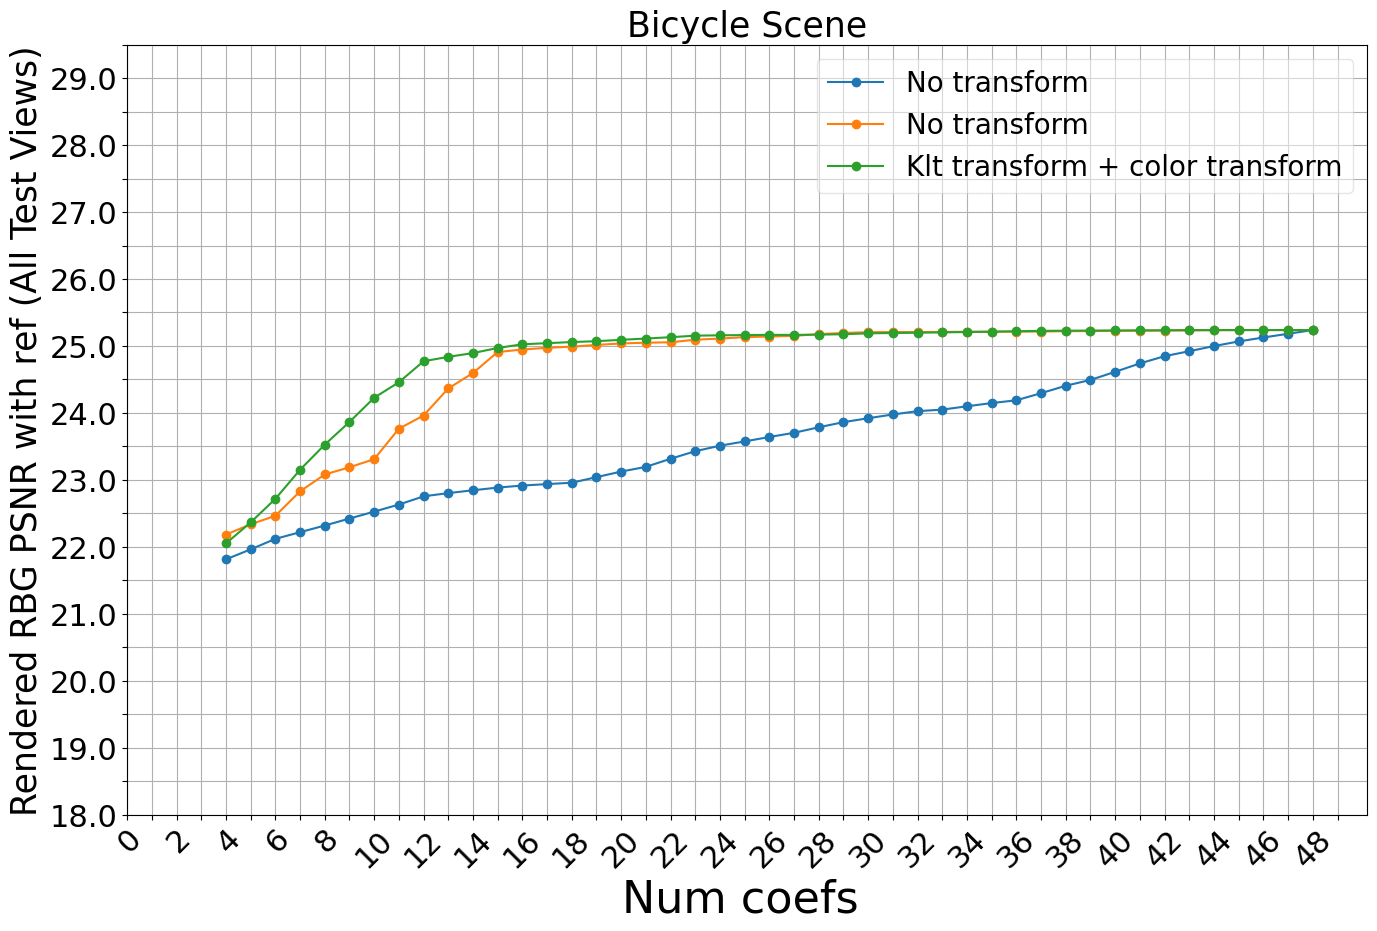

In [20]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 10))


## BASELINE 
psnr = [12.8319, 14.5228, 21.6947, 21.8129, 21.9618, 22.1188, 22.2181, 22.3181, 22.4220, 22.5255, 22.6310, 22.7537, 22.8021, 22.8444, 22.8844, 22.9152, 22.9366, 22.9571, 23.0406, 23.1239, 23.1940, 23.3150, 23.4278, 23.5104, 23.5742, 23.6401, 23.7030, 23.7853, 23.8620, 23.9202, 23.9766, 24.0260, 24.0489, 24.0989, 24.1469, 24.1885, 24.2948, 24.4052, 24.4926, 24.6138, 24.7391, 24.8468, 24.9218, 24.9983, 25.0672, 25.1263, 25.1816, 25.2373]
ax.plot(list(range(1, 49))[3:], psnr[3:], '-o', label="No transform")

psnr = [20.5678, 21.6197, 21.7794, 22.1825, 22.3361, 22.4636, 22.8286, 23.0805, 23.1874, 23.3093, 23.7635, 23.9610, 24.3649, 24.5958, 24.9093, 24.9465, 24.9721, 24.9896, 25.0151, 25.0373, 25.0486, 25.0545, 25.0934, 25.1100, 25.1314, 25.1409, 25.1512, 25.1765, 25.1939, 25.2054, 25.2076, 25.2078, 25.2094, 25.2116, 25.2127, 25.2136, 25.2151, 25.2203, 25.2221, 25.2257, 25.2277, 25.2301, 25.2309, 25.2346, 25.2369, 25.2372, 25.2373, 25.2373]
ax.plot(list(range(1, 49))[3:], psnr[3:], '-o', label="No transform")

psnr = [20.7020, 21.6929, 21.8319, 22.0499, 22.3648, 22.7161, 23.1515, 23.5257, 23.8647, 24.2262, 24.4574, 24.7715, 24.8371, 24.8936, 24.9698, 25.0248, 25.0414, 25.0581, 25.0710, 25.0913, 25.1109, 25.1304, 25.1536, 25.1586, 25.1626, 25.1656, 25.1645, 25.1691, 25.1751, 25.1885, 25.1932, 25.1974, 25.2024, 25.2084, 25.2126, 25.2198, 25.2251, 25.2278, 25.2297, 25.2308, 25.2322, 25.2337, 25.2371, 25.2371, 25.2372, 25.2372, 25.2373, 25.2373]
ax.plot(list(range(1, 49))[3:], psnr[3:], '-o', label="Klt transform + color transform")


############ 
yticks = np.arange(18, 30, step=0.5)
plt.yticks(ticks=yticks, labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(yticks)], fontsize=22)
xticks = np.arange(0, 50, step=1)
plt.xticks(ticks=xticks, labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(xticks)], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
plt.ylabel('Rendered RBG PSNR with ref (All Test Views)', fontsize=25)
plt.title('Bicycle Scene', fontsize=25)

In [ ]:
 12.7290, 14.3743, 20.3718, 20.3911, 20.4122, 20.4391, 20.4670, 20.4786, 20.5116, 20.6279, 20.7441, 20.8672, 20.9189, 20.9874, 21.0354, 21.0471, 21.0627, 21.0811, 21.1077, 21.1455, 21.1722, 21.2340, 21.2771, 21.3177, 21.3284, 21.3873, 21.4228, 21.4629, 21.5268, 21.5906, 21.6786, 21.7766, 21.8277, 21.8088, 21.8029, 21.8153, 21.8636, 21.9050, 21.9301, 21.9323, 21.9108, 21.9141, 21.8342, 21.7458, 21.6875, 21.6999, 21.7116, 21.7301,

In [ ]:
 18.9530, 20.1842, 20.2604, 20.6566, 20.8268, 21.0275, 21.1429, 21.2024, 21.4056, 21.6495, 21.4557, 21.7102, 21.4837, 21.6152, 21.5807, 21.6168, 21.6381, 21.6208, 21.6549, 21.6496, 21.6448, 21.6821, 21.6893, 21.6892, 21.6934, 21.6987, 21.7067, 21.7134, 21.7169, 21.7210, 21.7204, 21.7201, 21.7223, 21.7221, 21.7214, 21.7213, 21.7238, 21.7255, 21.7261, 21.7276, 21.7284, 21.7278, 21.7272, 21.7296, 21.7301, 21.7301, 21.7301, 21.7301,

In [ ]:
19.6665, 20.9812, 21.1637, 21.2306, 21.5245, 21.3747, 21.4488, 21.4636, 21.4766, 21.4796, 21.6228, 21.6218, 21.6245, 21.6906, 21.6983, 21.6844, 21.6972, 21.6909, 21.6767, 21.6822, 21.6835, 21.6635, 21.6674, 21.6685, 21.6889, 21.6910, 21.6937, 21.6872, 21.7556, 21.7240, 21.7231, 21.7245, 21.7108, 21.7113, 21.7108, 21.7147, 21.7192, 21.7200, 21.7203, 21.7299, 21.7302, 21.7304, 21.7302, 21.7303, 21.7305, 21.7301, 21.7301, 21.7301,

Text(0.5, 1.0, 'Bicycle Scene')

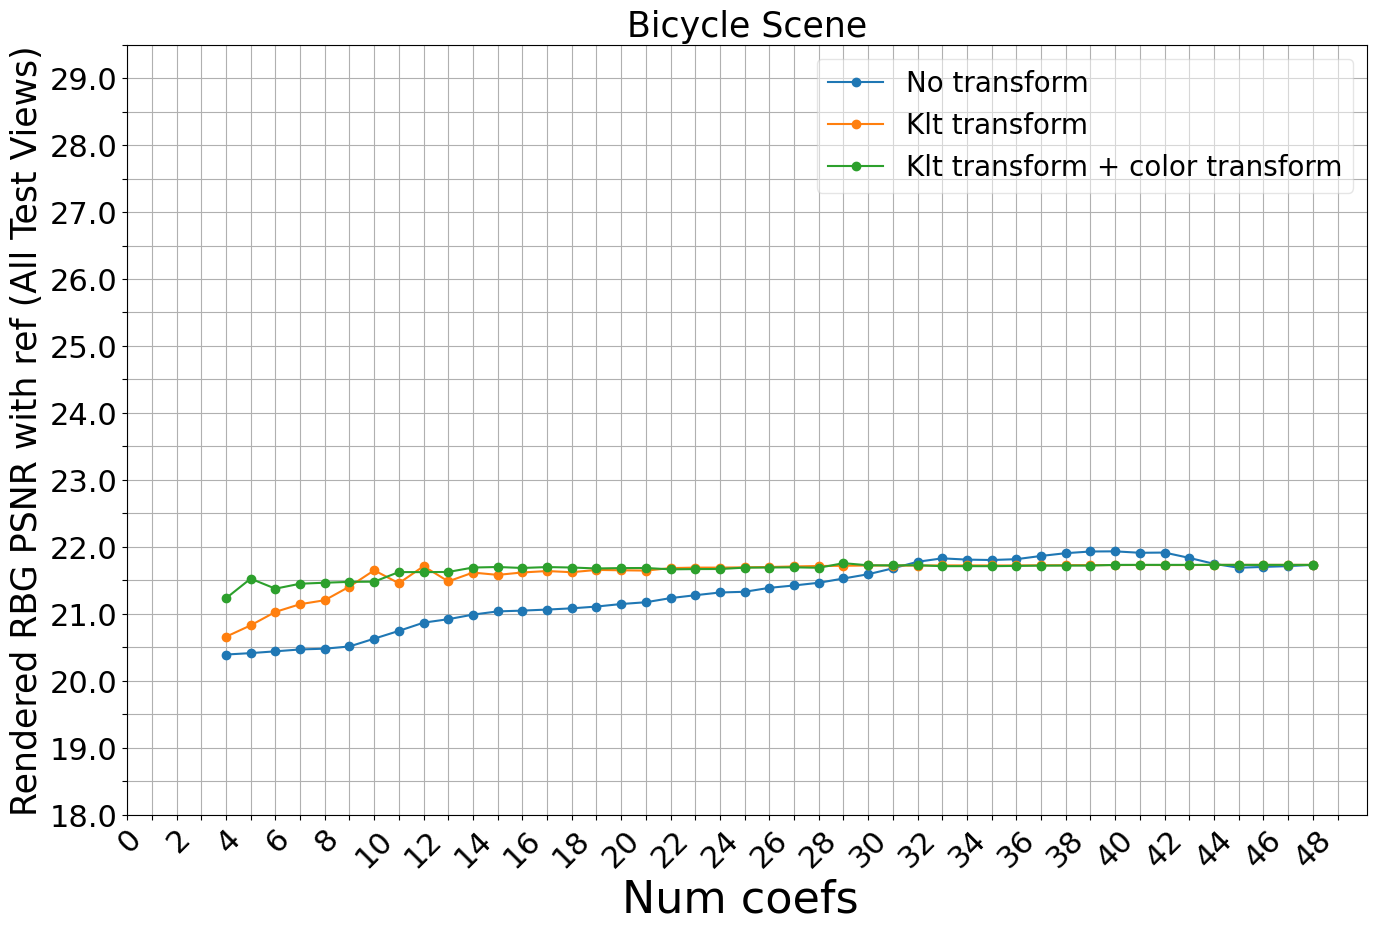

In [20]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 10))


## BASELINE 
psnr = [ 12.7290, 14.3743, 20.3718, 20.3911, 20.4122, 20.4391, 20.4670, 20.4786, 20.5116, 20.6279, 20.7441, 20.8672, 20.9189, 20.9874, 21.0354, 21.0471, 21.0627, 21.0811, 21.1077, 21.1455, 21.1722, 21.2340, 21.2771, 21.3177, 21.3284, 21.3873, 21.4228, 21.4629, 21.5268, 21.5906, 21.6786, 21.7766, 21.8277, 21.8088, 21.8029, 21.8153, 21.8636, 21.9050, 21.9301, 21.9323, 21.9108, 21.9141, 21.8342, 21.7458, 21.6875, 21.6999, 21.7116, 21.7301]
ax.plot(list(range(1, 49))[3:], psnr[3:], '-o', label="No transform")

psnr = [ 18.9530, 20.1842, 20.2604, 20.6566, 20.8268, 21.0275, 21.1429, 21.2024, 21.4056, 21.6495, 21.4557, 21.7102, 21.4837, 21.6152, 21.5807, 21.6168, 21.6381, 21.6208, 21.6549, 21.6496, 21.6448, 21.6821, 21.6893, 21.6892, 21.6934, 21.6987, 21.7067, 21.7134, 21.7169, 21.7210, 21.7204, 21.7201, 21.7223, 21.7221, 21.7214, 21.7213, 21.7238, 21.7255, 21.7261, 21.7276, 21.7284, 21.7278, 21.7272, 21.7296, 21.7301, 21.7301, 21.7301, 21.7301]
ax.plot(list(range(1, 49))[3:], psnr[3:], '-o', label="Klt transform")

psnr = [ 19.6665, 20.9812, 21.1637, 21.2306, 21.5245, 21.3747, 21.4488, 21.4636, 21.4766, 21.4796, 21.6228, 21.6218, 21.6245, 21.6906, 21.6983, 21.6844, 21.6972, 21.6909, 21.6767, 21.6822, 21.6835, 21.6635, 21.6674, 21.6685, 21.6889, 21.6910, 21.6937, 21.6872, 21.7556, 21.7240, 21.7231, 21.7245, 21.7108, 21.7113, 21.7108, 21.7147, 21.7192, 21.7200, 21.7203, 21.7299, 21.7302, 21.7304, 21.7302, 21.7303, 21.7305, 21.7301, 21.7301, 21.7301]
ax.plot(list(range(1, 49))[3:], psnr[3:], '-o', label="Klt transform + color transform")


############ 
yticks = np.arange(18, 30, step=0.5)
plt.yticks(ticks=yticks, labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(yticks)], fontsize=22)
xticks = np.arange(0, 50, step=1)
plt.xticks(ticks=xticks, labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(xticks)], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
plt.ylabel('Rendered RBG PSNR with ref (All Test Views)', fontsize=25)
plt.title('Bicycle Scene', fontsize=25)